正在构建邻接图与聚类...


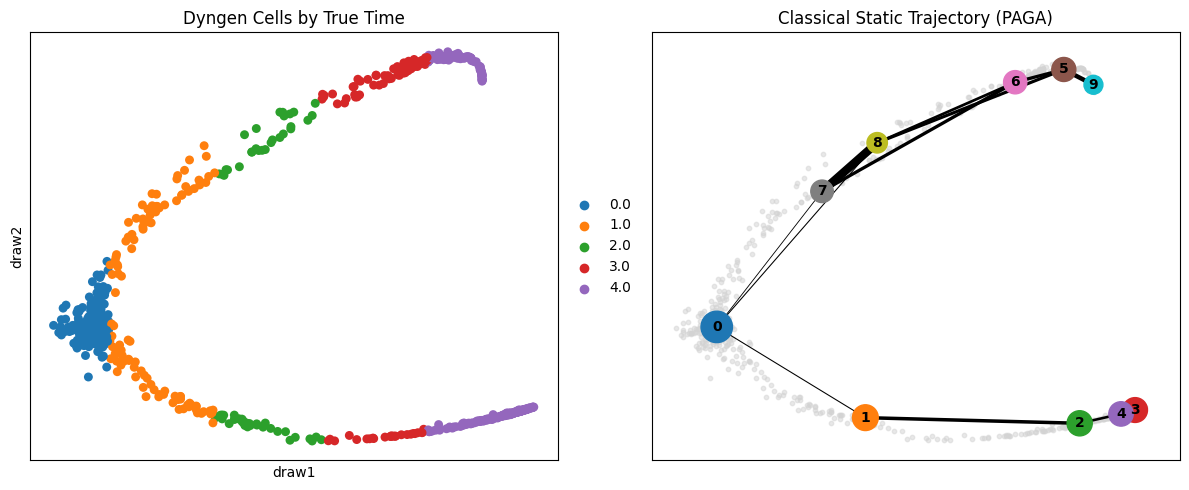

In [6]:
import pandas as pd
import numpy as np
import scanpy as sc
import anndata as ad
import matplotlib.pyplot as plt

data_name = 'dygen'



data = pd.read_csv('data/dygen.csv')






# Xs[k] are data points from time point k

Xs = []

mass_ratio = []

max_sample_time = int(np.max(data['samples']))

for k in range(max_sample_time + 1):

    Xs.append(np.array(data[data['samples'] == k])[:, 1:])

    mass_ratio.append(Xs[k].shape[0]/Xs[0].shape[0])



dim = Xs[0].shape[1]

t_train = np.arange(len(Xs)).tolist()

samples_per_interval = np.array(data).shape[0]

# ==========================================
# 1. 整合数据并构建 AnnData 对象
# ==========================================
# 你的 data['samples'] 是时间点，后面的列是特征坐标 (e.g., 5D PHATE)
timepoints = data['samples'].values
# 提取所有坐标数据 (N_cells, dim)
coords = data.iloc[:, 1:].values

# 构建 Scanpy 的核心数据结构 AnnData
adata = ad.AnnData(X=coords)
# 将时间转为类别型 (Categorical)，方便后续着色
adata.obs['time'] = pd.Categorical(timepoints) 

# 取前两维坐标作为展示底图 (如果你的数据本来就是 2D，这里就是全部数据)
adata.obsm['X_draw'] = coords[:, :2]

# ==========================================
# 2. 绕过 PCA/UMAP，直接在输入坐标上构建拓扑图
# ==========================================
print("正在构建邻接图与聚类...")
# 核心设置：use_rep='X' 强制算法直接使用你的 coords 计算距离，绝对不降维
sc.pp.neighbors(adata, n_neighbors=15, use_rep='X')

# PAGA 需要基于聚类碎片来连结轨迹，这里使用标准 Leiden 聚类
# resolution 决定了节点(分支)的多少，0.5 是一个适中的值，如果有需要可以微调
sc.tl.leiden(adata, resolution=0.3)

# 运行 PAGA 算法提取轨迹骨架
sc.tl.paga(adata, groups='leiden')

# ==========================================
# 3. 计算聚类中心，强制将骨架对齐到你的坐标系
# ==========================================
cluster_centers = []
for cluster in adata.obs['leiden'].cat.categories:
    # 提取属于该聚类的所有细胞的 2D 坐标
    mask = adata.obs['leiden'] == cluster
    center = adata.obsm['X_draw'][mask].mean(axis=0)
    cluster_centers.append(center)
    
cluster_centers = np.array(cluster_centers)

# ==========================================
# 4. 可视化：细胞散点图 vs PAGA 静态轨迹树
# ==========================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# 左图：纯粹的细胞分布，按真实时间点着色
sc.pl.embedding(adata, basis='draw', color='time', ax=ax1, show=False, title='Dyngen Cells by True Time')

# 右图：背景铺上灰色细胞，前景画上 PAGA 骨架
# 先画一层灰色背景细胞
ax2.scatter(adata.obsm['X_draw'][:, 0], adata.obsm['X_draw'][:, 1], 
            c='lightgray', s=10, alpha=0.5, zorder=0)

# 使用 PAGA 绘图，通过 pos 参数把节点定在你原本的坐标中心上
# color='time' 会自动用该聚类中最主流的时间点给节点上色
sc.pl.paga(adata, pos=cluster_centers, 
           node_size_scale=2.0, edge_width_scale=1.5, 
           ax=ax2, show=False, title='Classical Static Trajectory (PAGA)')

plt.tight_layout()
plt.savefig('Dyngen_PAGA.png')
plt.show()

正在构建邻接图与聚类...


/home/sirin/anaconda3/envs/sc_env/lib/python3.9/site-packages/scipy/sparse/_index.py:143: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil_matrix is more efficient.
  self._set_arrayXarray(i, j, x)


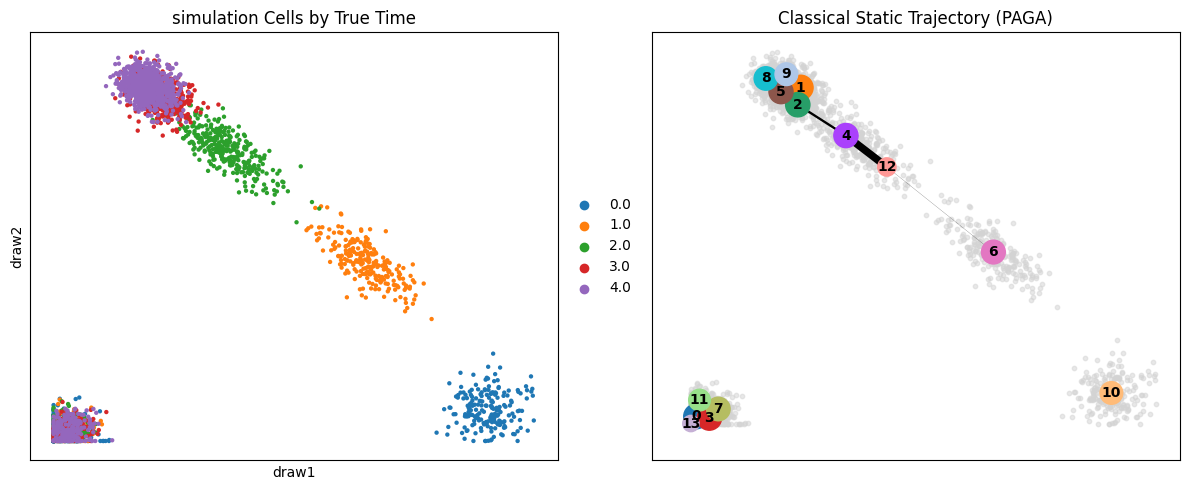

In [5]:
import pandas as pd
import numpy as np
import scanpy as sc
import anndata as ad
import matplotlib.pyplot as plt

data_name = 'simulation_gene_data'



data = pd.read_csv('data/simulation_gene_data.csv')





# Xs[k] are data points from time point k

Xs = []

mass_ratio = []

max_sample_time = int(np.max(data['samples']))

for k in range(max_sample_time + 1):

    Xs.append(np.array(data[data['samples'] == k])[:, 1:])

    mass_ratio.append(Xs[k].shape[0]/Xs[0].shape[0])



dim = Xs[0].shape[1]

t_train = np.arange(len(Xs)).tolist()

samples_per_interval = np.array(data).shape[0]

# ==========================================
# 1. 整合数据并构建 AnnData 对象
# ==========================================
# 你的 data['samples'] 是时间点，后面的列是特征坐标 (e.g., 5D PHATE)
timepoints = data['samples'].values
# 提取所有坐标数据 (N_cells, dim)
coords = data.iloc[:, 1:].values

# 构建 Scanpy 的核心数据结构 AnnData
adata = ad.AnnData(X=coords)
# 将时间转为类别型 (Categorical)，方便后续着色
adata.obs['time'] = pd.Categorical(timepoints) 

# 取前两维坐标作为展示底图 (如果你的数据本来就是 2D，这里就是全部数据)
adata.obsm['X_draw'] = coords[:, :2]

# ==========================================
# 2. 绕过 PCA/UMAP，直接在输入坐标上构建拓扑图
# ==========================================
print("正在构建邻接图与聚类...")
# 核心设置：use_rep='X' 强制算法直接使用你的 coords 计算距离，绝对不降维
sc.pp.neighbors(adata, n_neighbors=15, use_rep='X')

# PAGA 需要基于聚类碎片来连结轨迹，这里使用标准 Leiden 聚类
# resolution 决定了节点(分支)的多少，0.5 是一个适中的值，如果有需要可以微调
sc.tl.leiden(adata, resolution=0.3)

# 运行 PAGA 算法提取轨迹骨架
sc.tl.paga(adata, groups='leiden')

# ==========================================
# 3. 计算聚类中心，强制将骨架对齐到你的坐标系
# ==========================================
cluster_centers = []
for cluster in adata.obs['leiden'].cat.categories:
    # 提取属于该聚类的所有细胞的 2D 坐标
    mask = adata.obs['leiden'] == cluster
    center = adata.obsm['X_draw'][mask].mean(axis=0)
    cluster_centers.append(center)
    
cluster_centers = np.array(cluster_centers)

# ==========================================
# 4. 可视化：细胞散点图 vs PAGA 静态轨迹树
# ==========================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# 左图：纯粹的细胞分布，按真实时间点着色
sc.pl.embedding(adata, basis='draw', color='time', ax=ax1, show=False, title='simulation Cells by True Time')

# 右图：背景铺上灰色细胞，前景画上 PAGA 骨架
# 先画一层灰色背景细胞
ax2.scatter(adata.obsm['X_draw'][:, 0], adata.obsm['X_draw'][:, 1], 
            c='lightgray', s=10, alpha=0.5, zorder=0)

# 使用 PAGA 绘图，通过 pos 参数把节点定在你原本的坐标中心上
# color='time' 会自动用该聚类中最主流的时间点给节点上色
sc.pl.paga(adata, pos=cluster_centers, 
           node_size_scale=2.0, edge_width_scale=1.5, 
           ax=ax2, show=False, title='Classical Static Trajectory (PAGA)')

plt.tight_layout()
plt.savefig('Simulation_PAGA.png')
plt.show()